In [3]:
import wfdb

record = wfdb.rdrecord(
    r"C:\Users\hrkap\OneDrive\Desktop\VitaTwin-AI project\datasets\raw\afdb\04015"
)

signal = record.p_signal[:,0]

print("Signal Length:", len(signal))

Signal Length: 9205760


In [4]:
print(signal[:10])

[-0.275 -0.295 -0.31  -0.315 -0.3   -0.32  -0.3   -0.3   -0.29  -0.28 ]


In [5]:
import numpy as np

window_size = 1250

segments = []

for i in range(0, len(signal) - window_size, window_size):
    segment = signal[i:i + window_size]
    segments.append(segment)

segments = np.array(segments)

print("Segments Shape:", segments.shape)

Segments Shape: (7364, 1250)


In [7]:
import wfdb

ann = wfdb.rdann(
    r"C:\Users\hrkap\OneDrive\Desktop\VitaTwin-AI project\datasets\raw\afdb\04015",
    'atr'
)

print(ann.symbol[:20])
print(ann.sample[:20])

['+', '+', '+', '+', '+', '+', '+', '+', '+', '+', '+', '+', '+', '+', '+']
[     30  102584  119604  121773  122194  133348  166857 1096245 1098054
 1135296 1139595 1422436 1423548 1459277 1460416]


In [8]:
print(ann.aux_note[:20])

['(N', '(AFIB', '(N', '(AFIB', '(N', '(AFIB', '(N', '(AFIB', '(N', '(AFIB', '(N', '(AFIB', '(N', '(AFIB', '(N']


In [10]:
for i in range(15):
    print(
        ann.sample[i],
        ann.aux_note[i]
    )

30 (N
102584 (AFIB
119604 (N
121773 (AFIB
122194 (N
133348 (AFIB
166857 (N
1096245 (AFIB
1098054 (N
1135296 (AFIB
1139595 (N
1422436 (AFIB
1423548 (N
1459277 (AFIB
1460416 (N


In [12]:
for i in range(15):
    print(
        ann.sample[i],
        ann.aux_note[i]
    )

30 (N
102584 (AFIB
119604 (N
121773 (AFIB
122194 (N
133348 (AFIB
166857 (N
1096245 (AFIB
1098054 (N
1135296 (AFIB
1139595 (N
1422436 (AFIB
1423548 (N
1459277 (AFIB
1460416 (N


most important part of Module 4.

In [13]:
rhythm_intervals = []

for i in range(len(ann.sample)-1):

    start = ann.sample[i]
    end = ann.sample[i+1]

    rhythm = ann.aux_note[i]

    rhythm_intervals.append(
        (start, end, rhythm)
    )

print("Total intervals:", len(rhythm_intervals))

print(rhythm_intervals[:5])

Total intervals: 14
[(np.int64(30), np.int64(102584), '(N'), (np.int64(102584), np.int64(119604), '(AFIB'), (np.int64(119604), np.int64(121773), '(N'), (np.int64(121773), np.int64(122194), '(AFIB'), (np.int64(122194), np.int64(133348), '(N')]


In [14]:
for interval in rhythm_intervals[:10]:
    print(interval)

(np.int64(30), np.int64(102584), '(N')
(np.int64(102584), np.int64(119604), '(AFIB')
(np.int64(119604), np.int64(121773), '(N')
(np.int64(121773), np.int64(122194), '(AFIB')
(np.int64(122194), np.int64(133348), '(N')
(np.int64(133348), np.int64(166857), '(AFIB')
(np.int64(166857), np.int64(1096245), '(N')
(np.int64(1096245), np.int64(1098054), '(AFIB')
(np.int64(1098054), np.int64(1135296), '(N')
(np.int64(1135296), np.int64(1139595), '(AFIB')


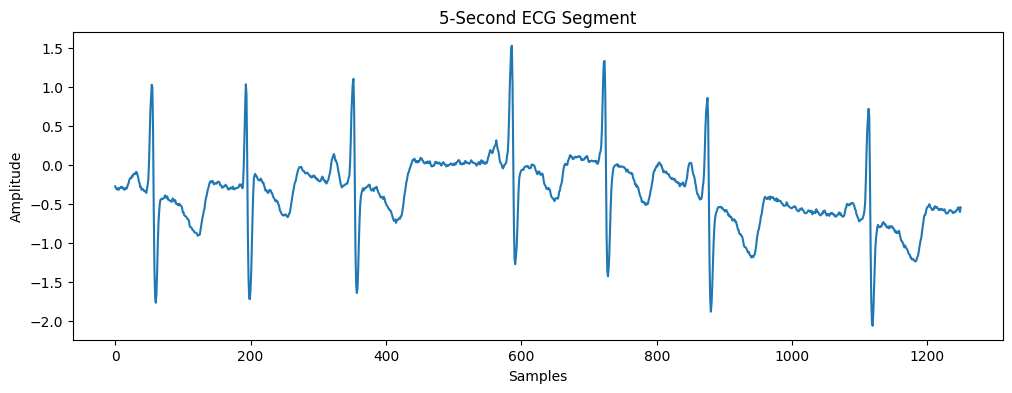

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(segments[0])

plt.title("5-Second ECG Segment")

plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

In [16]:
print(rhythm_intervals[:5])

[(np.int64(30), np.int64(102584), '(N'), (np.int64(102584), np.int64(119604), '(AFIB'), (np.int64(119604), np.int64(121773), '(N'), (np.int64(121773), np.int64(122194), '(AFIB'), (np.int64(122194), np.int64(133348), '(N')]


In [17]:
labels = []

window_size = 1250

for seg_idx in range(len(segments)):

    segment_start = seg_idx * window_size

    label = 0

    for start, end, rhythm in rhythm_intervals:

        if start <= segment_start < end:

            if "AFIB" in rhythm:
                label = 1
            else:
                label = 0

            break

    labels.append(label)

print("Total Labels:", len(labels))

Total Labels: 7364


In [18]:
print(labels[:50])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [19]:
import numpy as np

labels = np.array(labels)

print("Normal Segments :", np.sum(labels == 0))
print("AFIB Segments   :", np.sum(labels == 1))

Normal Segments : 7317
AFIB Segments   : 47


In [20]:
afib_intervals = []

for start, end, rhythm in rhythm_intervals:
    
    if "AFIB" in rhythm:
        
        duration = end - start
        
        afib_intervals.append(duration)

print("Number of AFIB intervals:", len(afib_intervals))

print("AFIB durations (first 10):")
print(afib_intervals[:10])

print("Total AFIB samples:")
print(sum(afib_intervals))

Number of AFIB intervals: 7
AFIB durations (first 10):
[np.int64(17020), np.int64(421), np.int64(33509), np.int64(1809), np.int64(4299), np.int64(1112), np.int64(1139)]
Total AFIB samples:
59309
